In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pydicom as dicom
import pandas as pd
import numpy as np
from PIL import Image

In [3]:
import torchxrayvision as xrv
import skimage
import torch, torchvision

# Dataset Loading

## ✅ NIH Dataset

In [111]:
csv_dir = r"/home/varrel/GitHub/CXR-Analysis/data/nih_chestxray14_Data_Entry_2017.csv"
train_dir = r"/home/varrel/GitHub/CXR-Analysis/data/nih_train_split.csv"
selection_dir = r"/home/varrel/GitHub/CXR-Analysis/data/nih_selection_split.csv"
test_dir = r"/home/varrel/GitHub/CXR-Analysis/data/nih_test_split.csv"

nih_sheet = pd.read_csv(csv_dir)
train_split = pd.read_csv(train_dir)
selection_split = pd.read_csv(selection_dir)
test_split = pd.read_csv(test_dir)

In [115]:
# Create Mask for NIH CSV
mask = nih_sheet['Image Index'].isin(train_split['Image Index'])
train_nih_sheet = nih_sheet.loc[mask]
train_nih_sheet.to_csv("nih_train_split_xrv.csv", index=False)

mask = nih_sheet['Image Index'].isin(selection_split['Image Index'])
selection_nih_sheet = nih_sheet.loc[mask]
selection_nih_sheet.to_csv("nih_selection_split_xrv.csv", index=False)

mask = nih_sheet['Image Index'].isin(test_split['Image Index'])
test_nih_sheet = nih_sheet.loc[mask]
test_nih_sheet.to_csv("nih_test_split_xrv.csv", index=False)

In [127]:
d_nih_train = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all",
                                       csvpath="nih_train_split_xrv.csv",
                                       views=["PA","AP"], unique_patients=False)

In [128]:
d_nih_selection = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all",
                                           csvpath="nih_selection_split_xrv.csv",
                                           views=["PA","AP"], unique_patients=False)

In [129]:
d_nih_test = xrv.datasets.NIH_Dataset(imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all",
                                      csvpath="nih_test_split_xrv.csv",
                                      views=["PA","AP"], unique_patients=False)

In [130]:
d_nih_train

{'Atelectasis': {np.float32(0.0): 80626, np.float32(1.0): 9279},
 'Cardiomegaly': {np.float32(0.0): 87720, np.float32(1.0): 2185},
 'Consolidation': {np.float32(0.0): 86163, np.float32(1.0): 3742},
 'Edema': {np.float32(0.0): 88069, np.float32(1.0): 1836},
 'Effusion': {np.float32(0.0): 79192, np.float32(1.0): 10713},
 'Emphysema': {np.float32(0.0): 87932, np.float32(1.0): 1973},
 'Fibrosis': {np.float32(0.0): 88535, np.float32(1.0): 1370},
 'Hernia': {np.float32(0.0): 89718, np.float32(1.0): 187},
 'Infiltration': {np.float32(0.0): 73963, np.float32(1.0): 15942},
 'Mass': {np.float32(0.0): 85252, np.float32(1.0): 4653},
 'Nodule': {np.float32(0.0): 84908, np.float32(1.0): 4997},
 'Pleural_Thickening': {np.float32(0.0): 87165, np.float32(1.0): 2740},
 'Pneumonia': {np.float32(0.0): 88758, np.float32(1.0): 1147},
 'Pneumothorax': {np.float32(0.0): 85561, np.float32(1.0): 4344}}


NIH_Dataset num_samples=89905 views=['PA', 'AP'] data_aug=None

In [131]:
d_nih_selection

{'Atelectasis': {np.float32(0.0): 10003, np.float32(1.0): 1151},
 'Cardiomegaly': {np.float32(0.0): 10858, np.float32(1.0): 296},
 'Consolidation': {np.float32(0.0): 10668, np.float32(1.0): 486},
 'Edema': {np.float32(0.0): 10914, np.float32(1.0): 240},
 'Effusion': {np.float32(0.0): 9853, np.float32(1.0): 1301},
 'Emphysema': {np.float32(0.0): 10880, np.float32(1.0): 274},
 'Fibrosis': {np.float32(0.0): 10995, np.float32(1.0): 159},
 'Hernia': {np.float32(0.0): 11132, np.float32(1.0): 22},
 'Infiltration': {np.float32(0.0): 9188, np.float32(1.0): 1966},
 'Mass': {np.float32(0.0): 10610, np.float32(1.0): 544},
 'Nodule': {np.float32(0.0): 10527, np.float32(1.0): 627},
 'Pleural_Thickening': {np.float32(0.0): 10842, np.float32(1.0): 312},
 'Pneumonia': {np.float32(0.0): 11013, np.float32(1.0): 141},
 'Pneumothorax': {np.float32(0.0): 10677, np.float32(1.0): 477}}


NIH_Dataset num_samples=11154 views=['PA', 'AP'] data_aug=None

In [132]:
d_nih_test

{'Atelectasis': {np.float32(0.0): 9932, np.float32(1.0): 1129},
 'Cardiomegaly': {np.float32(0.0): 10766, np.float32(1.0): 295},
 'Consolidation': {np.float32(0.0): 10622, np.float32(1.0): 439},
 'Edema': {np.float32(0.0): 10834, np.float32(1.0): 227},
 'Effusion': {np.float32(0.0): 9758, np.float32(1.0): 1303},
 'Emphysema': {np.float32(0.0): 10792, np.float32(1.0): 269},
 'Fibrosis': {np.float32(0.0): 10904, np.float32(1.0): 157},
 'Hernia': {np.float32(0.0): 11043, np.float32(1.0): 18},
 'Infiltration': {np.float32(0.0): 9075, np.float32(1.0): 1986},
 'Mass': {np.float32(0.0): 10476, np.float32(1.0): 585},
 'Nodule': {np.float32(0.0): 10354, np.float32(1.0): 707},
 'Pleural_Thickening': {np.float32(0.0): 10728, np.float32(1.0): 333},
 'Pneumonia': {np.float32(0.0): 10918, np.float32(1.0): 143},
 'Pneumothorax': {np.float32(0.0): 10580, np.float32(1.0): 481}}


NIH_Dataset num_samples=11061 views=['PA', 'AP'] data_aug=None

In [133]:
d_nih_test.csv.iloc[0]

index                                         0
Image Index                    00000032_000.png
Finding Labels                     Cardiomegaly
Follow-up #                                   0
Patient ID                                   32
Patient Age                                  55
Patient Gender                                F
View Position                                AP
OriginalImage[Width                        2500
Height]                                    2048
OriginalImagePixelSpacing[x               0.168
y]                                        0.168
Unnamed: 11                                 NaN
view                                         AP
has_masks                                 False
patientid                                    32
age_years                                  55.0
sex_male                                  False
sex_female                                 True
Name: 0, dtype: object

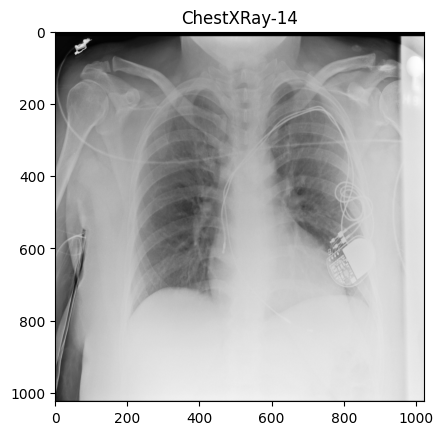

In [136]:
sample = d_nih_train[300]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("ChestXRay-14")
#plt.savefig("nih_chestxray14.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
dict(zip(d_nih.pathologies,sample["lab"]))

{'Atelectasis': np.float32(0.0),
 'Cardiomegaly': np.float32(0.0),
 'Consolidation': np.float32(0.0),
 'Edema': np.float32(0.0),
 'Effusion': np.float32(0.0),
 'Emphysema': np.float32(0.0),
 'Fibrosis': np.float32(0.0),
 'Hernia': np.float32(0.0),
 'Infiltration': np.float32(0.0),
 'Mass': np.float32(0.0),
 'Nodule': np.float32(0.0),
 'Pleural_Thickening': np.float32(0.0),
 'Pneumonia': np.float32(0.0),
 'Pneumothorax': np.float32(0.0)}

## ✅ Open-I Dataset

In [243]:
d_openi = xrv.datasets.Openi_Dataset(imgpath="/home/varrel/imaging/all_images/Openi_dataset/images_all",
                                     xmlpath="/home/varrel/imaging/all_images/Openi_dataset/reports_all/NLMCXR_reports.tgz",
                                     views=['AP', 'PA'])

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

labels = d_openi.labels
indices = np.arange(len(d_openi))

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(msss.split(indices, labels))

msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(msss2.split(temp_idx, labels[temp_idx]))

train_set = xrv.datasets.SubsetDataset(d_openi, train_idx)
val_set = xrv.datasets.SubsetDataset(d_openi, val_idx)
test_set = xrv.datasets.SubsetDataset(d_openi, test_idx)

In [250]:
val_set

{np.str_('Atelectasis'): {np.float32(0.0): 230, np.float32(1.0): 26},
 np.str_('Calcified Granuloma'): {np.float32(0.0): 245, np.float32(1.0): 11},
 np.str_('Cardiomegaly'): {np.float32(0.0): 243, np.float32(1.0): 13},
 np.str_('Edema'): {np.float32(0.0): 253, np.float32(1.0): 3},
 np.str_('Effusion'): {np.float32(0.0): 241, np.float32(1.0): 15},
 np.str_('Emphysema'): {np.float32(0.0): 252, np.float32(1.0): 4},
 np.str_('Fibrosis'): {np.float32(0.0): 254, np.float32(1.0): 2},
 np.str_('Fracture'): {np.float32(0.0): 252, np.float32(1.0): 4},
 np.str_('Granuloma'): {np.float32(0.0): 233, np.float32(1.0): 23},
 np.str_('Hernia'): {np.float32(0.0): 250, np.float32(1.0): 6},
 np.str_('Infiltration'): {np.float32(0.0): 249, np.float32(1.0): 7},
 np.str_('Lung Lesion'): {np.float32(0.0): 256},
 np.str_('Lung Opacity'): {np.float32(0.0): 226, np.float32(1.0): 30},
 np.str_('Mass'): {np.float32(0.0): 255, np.float32(1.0): 1},
 np.str_('Nodule'): {np.float32(0.0): 250, np.float32(1.0): 6},
 np.

SubsetDataset num_samples=256
└ of Openi_Dataset num_samples=2561

In [32]:
d_openi.csv.iloc[50]["labels_major"]

'atherosclerosis/aorta, thoracic|thoracic vertebrae/degenerative/mild'

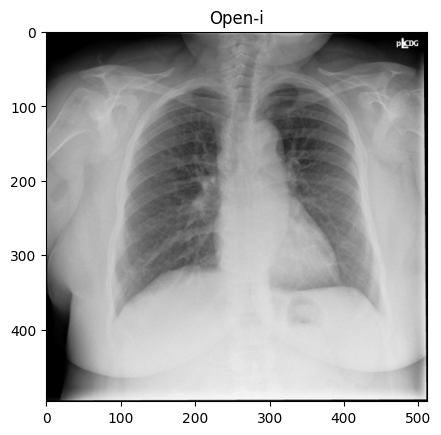

In [40]:
sample = d_openi[43]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("Open-i")
plt.savefig("openi.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
dict(zip(d_openi.pathologies,sample["lab"]))

{np.str_('Atelectasis'): np.float32(0.0),
 np.str_('Calcified Granuloma'): np.float32(0.0),
 np.str_('Cardiomegaly'): np.float32(0.0),
 np.str_('Edema'): np.float32(0.0),
 np.str_('Effusion'): np.float32(0.0),
 np.str_('Emphysema'): np.float32(0.0),
 np.str_('Fibrosis'): np.float32(0.0),
 np.str_('Fracture'): np.float32(0.0),
 np.str_('Granuloma'): np.float32(0.0),
 np.str_('Hernia'): np.float32(0.0),
 np.str_('Infiltration'): np.float32(0.0),
 np.str_('Lung Lesion'): np.float32(0.0),
 np.str_('Mass'): np.float32(0.0),
 np.str_('Nodule'): np.float32(0.0),
 np.str_('Lung Opacity'): np.float32(0.0),
 np.str_('Pleural_Thickening'): np.float32(0.0),
 np.str_('Pneumonia'): np.float32(0.0),
 np.str_('Pneumothorax'): np.float32(0.0)}

## ✅ VinDr Dataset

In [220]:
d_vin_train = xrv.datasets.VinBrain_Dataset(imgpath=r"/home/varrel/imaging/all_images/VinDr_dataset/images_all",
                                      csvpath=r"/home/varrel/GitHub/CXR-Analysis/data/vin_train_split.csv")
d_vin_selection = xrv.datasets.VinBrain_Dataset(imgpath=r"/home/varrel/imaging/all_images/VinDr_dataset/images_all",
                                      csvpath=r"/home/varrel/GitHub/CXR-Analysis/data/vin_selection_split.csv")
d_vin_test = xrv.datasets.VinBrain_Dataset(imgpath=r"/home/varrel/test_images/test_dataset/VinDr_dataset/images_all",
                                      csvpath=r"/home/varrel/imaging/all_images/VinDr_dataset/annotations_test.csv")

In [221]:
d_vin_train

{np.str_('Aortic enlargement'): {np.float32(0.0): 10709, np.float32(1.0): 2786},
 np.str_('Atelectasis'): {np.float32(0.0): 13327, np.float32(1.0): 168},
 np.str_('Calcification'): {np.float32(0.0): 13083, np.float32(1.0): 412},
 np.str_('Cardiomegaly'): {np.float32(0.0): 11408, np.float32(1.0): 2087},
 np.str_('Consolidation'): {np.float32(0.0): 13176, np.float32(1.0): 319},
 np.str_('Effusion'): {np.float32(0.0): 12564, np.float32(1.0): 931},
 np.str_('ILD'): {np.float32(0.0): 13137, np.float32(1.0): 358},
 np.str_('Infiltration'): {np.float32(0.0): 12941, np.float32(1.0): 554},
 np.str_('Lesion'): {np.float32(0.0): 12448, np.float32(1.0): 1047},
 np.str_('Lung Opacity'): {np.float32(0.0): 12297, np.float32(1.0): 1198},
 np.str_('Nodule/Mass'): {np.float32(0.0): 12731, np.float32(1.0): 764},
 np.str_('Pleural_Thickening'): {np.float32(0.0): 11689, np.float32(1.0): 1806},
 np.str_('Pneumothorax'): {np.float32(0.0): 13409, np.float32(1.0): 86},
 np.str_('Pulmonary Fibrosis'): {np.float

VinBrain_Dataset num_samples=13495 views=None data_aug=None

In [222]:
d_vin_selection

{np.str_('Aortic enlargement'): {np.float32(0.0): 1193, np.float32(1.0): 312},
 np.str_('Atelectasis'): {np.float32(0.0): 1486, np.float32(1.0): 19},
 np.str_('Calcification'): {np.float32(0.0): 1459, np.float32(1.0): 46},
 np.str_('Cardiomegaly'): {np.float32(0.0): 1276, np.float32(1.0): 229},
 np.str_('Consolidation'): {np.float32(0.0): 1471, np.float32(1.0): 34},
 np.str_('Effusion'): {np.float32(0.0): 1398, np.float32(1.0): 107},
 np.str_('ILD'): {np.float32(0.0): 1466, np.float32(1.0): 39},
 np.str_('Infiltration'): {np.float32(0.0): 1446, np.float32(1.0): 59},
 np.str_('Lesion'): {np.float32(0.0): 1398, np.float32(1.0): 107},
 np.str_('Lung Opacity'): {np.float32(0.0): 1372, np.float32(1.0): 133},
 np.str_('Nodule/Mass'): {np.float32(0.0): 1428, np.float32(1.0): 77},
 np.str_('Pleural_Thickening'): {np.float32(0.0): 1301, np.float32(1.0): 204},
 np.str_('Pneumothorax'): {np.float32(0.0): 1495, np.float32(1.0): 10},
 np.str_('Pulmonary Fibrosis'): {np.float32(0.0): 1345, np.float3

VinBrain_Dataset num_samples=1505 views=None data_aug=None

In [217]:
d_vin_test

{np.str_('Aortic enlargement'): {np.float32(0.0): 2780, np.float32(1.0): 220},
 np.str_('Atelectasis'): {np.float32(0.0): 2914, np.float32(1.0): 86},
 np.str_('Calcification'): {np.float32(0.0): 2806, np.float32(1.0): 194},
 np.str_('Cardiomegaly'): {np.float32(0.0): 2691, np.float32(1.0): 309},
 np.str_('Consolidation'): {np.float32(0.0): 2904, np.float32(1.0): 96},
 np.str_('Effusion'): {np.float32(0.0): 2889, np.float32(1.0): 111},
 np.str_('ILD'): {np.float32(0.0): 2779, np.float32(1.0): 221},
 np.str_('Infiltration'): {np.float32(0.0): 2942, np.float32(1.0): 58},
 np.str_('Lesion'): {np.float32(0.0): 2906, np.float32(1.0): 94},
 np.str_('Lung Opacity'): {np.float32(0.0): 2916, np.float32(1.0): 84},
 np.str_('Nodule/Mass'): {np.float32(0.0): 2824, np.float32(1.0): 176},
 np.str_('Pleural_Thickening'): {np.float32(0.0): 2831, np.float32(1.0): 169},
 np.str_('Pneumothorax'): {np.float32(0.0): 2982, np.float32(1.0): 18},
 np.str_('Pulmonary Fibrosis'): {np.float32(0.0): 2783, np.float

VinBrain_Dataset num_samples=3000 views=None data_aug=None

In [218]:
d_vin_test.csv.iloc[1255]

image_id      6fdc6a34720c31d685942b7bb44f9612
class_name                          No finding
has_masks                                False
Name: 1255, dtype: object

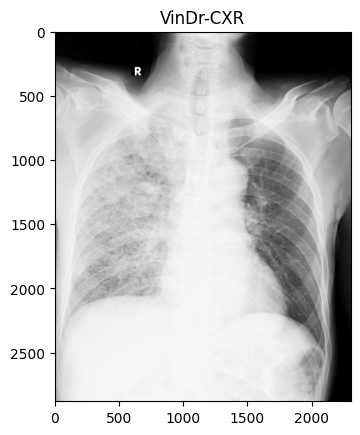

In [224]:
sample = d_vin_selection[277]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("VinDr-CXR")
#plt.savefig("vindr.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
dict(zip(d_vin.pathologies,sample["lab"]))

{np.str_('Aortic enlargement'): np.float32(0.0),
 np.str_('Atelectasis'): np.float32(0.0),
 np.str_('Calcification'): np.float32(0.0),
 np.str_('Cardiomegaly'): np.float32(0.0),
 np.str_('Consolidation'): np.float32(0.0),
 np.str_('Effusion'): np.float32(0.0),
 np.str_('ILD'): np.float32(0.0),
 np.str_('Infiltration'): np.float32(0.0),
 np.str_('Lesion'): np.float32(0.0),
 np.str_('Lung Opacity'): np.float32(0.0),
 np.str_('Nodule/Mass'): np.float32(0.0),
 np.str_('Pleural_Thickening'): np.float32(0.0),
 np.str_('Pneumothorax'): np.float32(0.0),
 np.str_('Pulmonary Fibrosis'): np.float32(0.0)}

### VinDr Fix Annotations

In [62]:
annotations_train_dir = r"/home/varrel/all_images/VinDr_dataset/annotations_train.csv"

annotations_train_sheet = pd.read_csv(annotations_train_dir)
annotations_train_sheet

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN
3,00053190460d56c53cc3e57321387478,R11,No finding,NaN,NaN,NaN,NaN
4,00053190460d56c53cc3e57321387478,R2,No finding,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
69047,fff0f82159f9083f3dd1f8967fc54f6a,R8,No finding,NaN,NaN,NaN,NaN
69048,fff0f82159f9083f3dd1f8967fc54f6a,R9,No finding,NaN,NaN,NaN,NaN
69049,fff2025e3c1d6970a8a6ee0404ac6940,R1,No finding,NaN,NaN,NaN,NaN
69050,fff2025e3c1d6970a8a6ee0404ac6940,R2,No finding,NaN,NaN,NaN,NaN


In [64]:
annotations_test_dir = r"/home/varrel/all_images/VinDr_dataset/annotations_test.csv"

annotations_test_sheet = pd.read_csv(annotations_test_dir)
annotations_test_sheet

,image_id,class_name,x_min,y_min,x_max,y_max
0,e0dc2e79105ad93532484e956ef8a71a,Calcification,1221.560976,661.580417,1343.298780,783.318222
1,e0dc2e79105ad93532484e956ef8a71a,Cardiomegaly,638.695122,1310.848710,1800.737805,1937.982856
2,e0dc2e79105ad93532484e956ef8a71a,ILD,1693.756098,1392.007246,1929.853659,1941.671881
3,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,399.924053,145.803282,1016.600328,510.138208
4,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,334.300846,493.762382,453.145487,744.509170
...,...,...,...,...,...,...
4743,9e8a5a85012b7b8c5dd164382d93e089,No finding,NaN,NaN,NaN,NaN
4744,8b9ea72de468504f3dbc3fc711f905a3,No finding,NaN,NaN,NaN,NaN
4745,b6c2293402377da9dc28dc65609022f0,No finding,NaN,NaN,NaN,NaN
4746,84564d34f32254f20e49bcb6ab603421,No finding,NaN,NaN,NaN,NaN


In [65]:
annotations_test_sheet['rad_id'] = 'R1'

In [67]:
cols = annotations_test_sheet.columns.tolist()
new_order = [cols[0], 'rad_id'] + [col for col in cols if col not in [cols[0], 'rad_id']]
annotations_test_sheet = annotations_test_sheet[new_order]
annotations_test_sheet

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,e0dc2e79105ad93532484e956ef8a71a,R1,Calcification,1221.560976,661.580417,1343.298780,783.318222
1,e0dc2e79105ad93532484e956ef8a71a,R1,Cardiomegaly,638.695122,1310.848710,1800.737805,1937.982856
2,e0dc2e79105ad93532484e956ef8a71a,R1,ILD,1693.756098,1392.007246,1929.853659,1941.671881
3,e0dc2e79105ad93532484e956ef8a71a,R1,Pneumothorax,399.924053,145.803282,1016.600328,510.138208
4,e0dc2e79105ad93532484e956ef8a71a,R1,Pneumothorax,334.300846,493.762382,453.145487,744.509170
...,...,...,...,...,...,...,...
4743,9e8a5a85012b7b8c5dd164382d93e089,R1,No finding,NaN,NaN,NaN,NaN
4744,8b9ea72de468504f3dbc3fc711f905a3,R1,No finding,NaN,NaN,NaN,NaN
4745,b6c2293402377da9dc28dc65609022f0,R1,No finding,NaN,NaN,NaN,NaN
4746,84564d34f32254f20e49bcb6ab603421,R1,No finding,NaN,NaN,NaN,NaN


In [68]:
combined_df = pd.concat([annotations_train_sheet, annotations_test_sheet], axis=0, ignore_index=True)
combined_df

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN
3,00053190460d56c53cc3e57321387478,R11,No finding,NaN,NaN,NaN,NaN
4,00053190460d56c53cc3e57321387478,R2,No finding,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
73795,9e8a5a85012b7b8c5dd164382d93e089,R1,No finding,NaN,NaN,NaN,NaN
73796,8b9ea72de468504f3dbc3fc711f905a3,R1,No finding,NaN,NaN,NaN,NaN
73797,b6c2293402377da9dc28dc65609022f0,R1,No finding,NaN,NaN,NaN,NaN
73798,84564d34f32254f20e49bcb6ab603421,R1,No finding,NaN,NaN,NaN,NaN


In [69]:
combined_df.to_csv(r"/home/varrel/all_images/VinDr_dataset/combined_annotations.csv", index=False)

## ✅ PadChest

In [227]:
csv_dir = r"/home/varrel/GitHub/CXR-Analysis/data/padchest_chest_x_ray_images_labels_160K_01.02.19.csv"
train_dir = r"/home/varrel/GitHub/CXR-Analysis/data/padchest_train_split.csv"
selection_dir = r"/home/varrel/GitHub/CXR-Analysis/data/padchest_selection_split.csv"
test_dir = r"/home/varrel/GitHub/CXR-Analysis/data/padchest_test_split.csv"

padchest_sheet = pd.read_csv(csv_dir)
train_split = pd.read_csv(train_dir)
selection_split = pd.read_csv(selection_dir)
test_split = pd.read_csv(test_dir)

In [229]:
# Create Mask for NIH CSV
mask = padchest_sheet['ImageID'].isin(train_split['ImageID'])
train_pc_sheet = padchest_sheet.loc[mask]
train_pc_sheet.to_csv("pc_train_split_xrv.csv", index=False)

mask = padchest_sheet['ImageID'].isin(selection_split['ImageID'])
selection_pc_sheet = padchest_sheet.loc[mask]
selection_pc_sheet.to_csv("pc_selection_split_xrv.csv", index=False)

mask = padchest_sheet['ImageID'].isin(test_split['ImageID'])
test_pc_sheet = padchest_sheet.loc[mask]
test_pc_sheet.to_csv("pc_test_split_xrv.csv", index=False)

In [ ]:
d_pc_train = xrv.datasets.PC_Dataset(imgpath="/home/varrel/imaging/BIMCV-PadChest-FULL",
                                     flat_dir=False,
                                     csvpath="pc_train_split_xrv.csv",
                                     views=["PA","AP", "L"], unique_patients=False)
d_pc_selection = xrv.datasets.PC_Dataset(imgpath="/home/varrel/imaging/all_images/PC_dataset/images_all",
                                         csvpath="pc_selection_split_xrv.csv",
                                         views=["PA","AP", "L"], unique_patients=False)
d_pc_test = xrv.datasets.PC_Dataset(imgpath="/home/varrel/imaging/all_images/PC_dataset/images_all",
                                    csvpath="pc_test_split_xrv.csv",
                                    views=["PA","AP", "L"], unique_patients=False)

In [233]:
d_pc_train

{'Air Trapping': {np.float32(0.0): 110184, np.float32(1.0): 4816},
 'Aortic Atheromatosis': {np.float32(0.0): 113086, np.float32(1.0): 1914},
 'Aortic Elongation': {np.float32(0.0): 105938, np.float32(1.0): 9062},
 'Atelectasis': {np.float32(0.0): 109321, np.float32(1.0): 5679},
 'Bronchiectasis': {np.float32(0.0): 112864, np.float32(1.0): 2136},
 'Cardiomegaly': {np.float32(0.0): 103961, np.float32(1.0): 11039},
 'Consolidation': {np.float32(0.0): 113471, np.float32(1.0): 1529},
 'Costophrenic Angle Blunting': {np.float32(0.0): 110123,
                                 np.float32(1.0): 4877},
 'Edema': {np.float32(0.0): 114519, np.float32(1.0): 481},
 'Effusion': {np.float32(0.0): 109619, np.float32(1.0): 5381},
 'Emphysema': {np.float32(0.0): 113687, np.float32(1.0): 1313},
 'Fibrosis': {np.float32(0.0): 114000, np.float32(1.0): 1000},
 'Flattened Diaphragm': {np.float32(0.0): 114234, np.float32(1.0): 766},
 'Fracture': {np.float32(0.0): 111672, np.float32(1.0): 3328},
 'Granuloma': {

PC_Dataset num_samples=115000 views=['PA', 'AP', 'L'] data_aug=None

In [235]:
d_pc_selection

{'Air Trapping': {np.float32(0.0): 13816, np.float32(1.0): 603},
 'Aortic Atheromatosis': {np.float32(0.0): 14182, np.float32(1.0): 237},
 'Aortic Elongation': {np.float32(0.0): 13278, np.float32(1.0): 1141},
 'Atelectasis': {np.float32(0.0): 13697, np.float32(1.0): 722},
 'Bronchiectasis': {np.float32(0.0): 14148, np.float32(1.0): 271},
 'Cardiomegaly': {np.float32(0.0): 13048, np.float32(1.0): 1371},
 'Consolidation': {np.float32(0.0): 14221, np.float32(1.0): 198},
 'Costophrenic Angle Blunting': {np.float32(0.0): 13841, np.float32(1.0): 578},
 'Edema': {np.float32(0.0): 14356, np.float32(1.0): 63},
 'Effusion': {np.float32(0.0): 13726, np.float32(1.0): 693},
 'Emphysema': {np.float32(0.0): 14272, np.float32(1.0): 147},
 'Fibrosis': {np.float32(0.0): 14328, np.float32(1.0): 91},
 'Flattened Diaphragm': {np.float32(0.0): 14315, np.float32(1.0): 104},
 'Fracture': {np.float32(0.0): 14004, np.float32(1.0): 415},
 'Granuloma': {np.float32(0.0): 14027, np.float32(1.0): 392},
 'Hemidiaphra

PC_Dataset num_samples=14419 views=['PA', 'AP', 'L'] data_aug=None

In [236]:
d_pc_test

{'Air Trapping': {np.float32(0.0): 14017, np.float32(1.0): 638},
 'Aortic Atheromatosis': {np.float32(0.0): 14359, np.float32(1.0): 296},
 'Aortic Elongation': {np.float32(0.0): 13468, np.float32(1.0): 1187},
 'Atelectasis': {np.float32(0.0): 13955, np.float32(1.0): 700},
 'Bronchiectasis': {np.float32(0.0): 14407, np.float32(1.0): 248},
 'Cardiomegaly': {np.float32(0.0): 13200, np.float32(1.0): 1455},
 'Consolidation': {np.float32(0.0): 14437, np.float32(1.0): 218},
 'Costophrenic Angle Blunting': {np.float32(0.0): 14018, np.float32(1.0): 637},
 'Edema': {np.float32(0.0): 14583, np.float32(1.0): 72},
 'Effusion': {np.float32(0.0): 13832, np.float32(1.0): 823},
 'Emphysema': {np.float32(0.0): 14517, np.float32(1.0): 138},
 'Fibrosis': {np.float32(0.0): 14556, np.float32(1.0): 99},
 'Flattened Diaphragm': {np.float32(0.0): 14536, np.float32(1.0): 119},
 'Fracture': {np.float32(0.0): 14262, np.float32(1.0): 393},
 'Granuloma': {np.float32(0.0): 14287, np.float32(1.0): 368},
 'Hemidiaphra

PC_Dataset num_samples=14655 views=['PA', 'AP', 'L'] data_aug=None

In [237]:
d_pc_train.csv.iloc[444]

Unnamed: 0                                                                       659
ImageID                            304915924317622679295931147228573929640_5yhm09...
ImageDir                                                                           0
StudyDate_DICOM                                                             20160928
StudyID                                      304915924317622679295931147228573929640
PatientID                                      9387999773577654046668972727559668758
PatientBirth                                                                  1985.0
PatientSex_DICOM                                                                   F
ViewPosition_DICOM                                                                PA
Projection                                                                        PA
MethodProjection                                       Manual review of DICOM fields
Pediatric                                                        

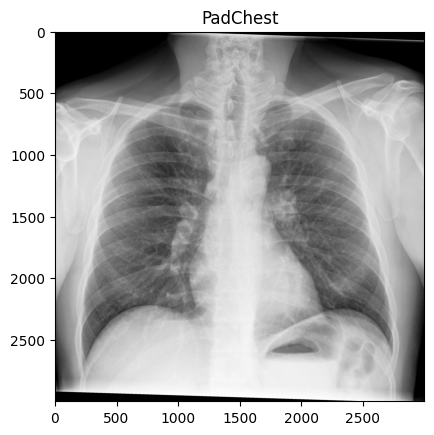

In [240]:
sample = d_pc_test[4627]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("PadChest")
#plt.savefig("padchest.png", dpi=300, bbox_inches="tight")
plt.show()

In [91]:
dict(zip(d_pc.pathologies,sample["lab"]))

{'Air Trapping': np.float32(0.0),
 'Aortic Atheromatosis': np.float32(0.0),
 'Aortic Elongation': np.float32(0.0),
 'Atelectasis': np.float32(0.0),
 'Bronchiectasis': np.float32(0.0),
 'Cardiomegaly': np.float32(0.0),
 'Consolidation': np.float32(0.0),
 'Costophrenic Angle Blunting': np.float32(0.0),
 'Edema': np.float32(0.0),
 'Effusion': np.float32(0.0),
 'Emphysema': np.float32(0.0),
 'Fibrosis': np.float32(0.0),
 'Flattened Diaphragm': np.float32(0.0),
 'Fracture': np.float32(0.0),
 'Granuloma': np.float32(0.0),
 'Hemidiaphragm Elevation': np.float32(0.0),
 'Hernia': np.float32(0.0),
 'Hilar Enlargement': np.float32(0.0),
 'Infiltration': np.float32(0.0),
 'Mass': np.float32(0.0),
 'Nodule': np.float32(0.0),
 'Pleural_Thickening': np.float32(0.0),
 'Pneumonia': np.float32(0.0),
 'Pneumothorax': np.float32(0.0),
 'Scoliosis': np.float32(0.0),
 'Support Devices': np.float32(0.0),
 'Tube': np.float32(0.0),
 'Tuberculosis': np.float32(0.0)}

## ✅ MIMIC Dataset

In [206]:
d_mimic_train = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/data/mimic_train_split.csv",
                                     metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                     views=["PA","AP","L"], unique_patients=False)
d_mimic_selection = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/data/mimic_selection_split.csv",
                                     metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                     views=["PA","AP","L"], unique_patients=False)
d_mimic_test = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all",
                                     csvpath="/home/varrel/GitHub/CXR-Analysis/data/mimic_test_split.csv",
                                     metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                     views=["PA","AP","L"], unique_patients=False)

In [207]:
d_mimic_train

{np.str_('Atelectasis'): {np.float32(0.0): 152432, np.float32(1.0): 38130},
 np.str_('Cardiomegaly'): {np.float32(0.0): 153353, np.float32(1.0): 37209},
 np.str_('Consolidation'): {np.float32(0.0): 181521, np.float32(1.0): 9041},
 np.str_('Edema'): {np.float32(0.0): 167620, np.float32(1.0): 22942},
 np.str_('Effusion'): {np.float32(0.0): 145605, np.float32(1.0): 44957},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 184609,
                                         np.float32(1.0): 5953},
 np.str_('Fracture'): {np.float32(0.0): 186836, np.float32(1.0): 3726},
 np.str_('Lung Lesion'): {np.float32(0.0): 185499, np.float32(1.0): 5063},
 np.str_('Lung Opacity'): {np.float32(0.0): 147935, np.float32(1.0): 42627},
 np.str_('Pleural Other'): {np.float32(0.0): 188951, np.float32(1.0): 1611},
 np.str_('Pneumonia'): {np.float32(0.0): 177174, np.float32(1.0): 13388},
 np.str_('Pneumothorax'): {np.float32(0.0): 181672, np.float32(1.0): 8890},
 np.str_('Support Devices'): {np.float32(0.0)

MIMIC_Dataset num_samples=190562 views=['PA', 'AP', 'L'] data_aug=None

In [208]:
d_mimic_selection

{np.str_('Atelectasis'): {np.float32(0.0): 21397, np.float32(1.0): 5407},
 np.str_('Cardiomegaly'): {np.float32(0.0): 21827, np.float32(1.0): 5049},
 np.str_('Consolidation'): {np.float32(0.0): 25693, np.float32(1.0): 1194},
 np.str_('Edema'): {np.float32(0.0): 23775, np.float32(1.0): 3030},
 np.str_('Effusion'): {np.float32(0.0): 20603, np.float32(1.0): 6287},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 25984,
                                         np.float32(1.0): 849},
 np.str_('Fracture'): {np.float32(0.0): 26459, np.float32(1.0): 516},
 np.str_('Lung Lesion'): {np.float32(0.0): 26156, np.float32(1.0): 807},
 np.str_('Lung Opacity'): {np.float32(0.0): 21074, np.float32(1.0): 5869},
 np.str_('Pleural Other'): {np.float32(0.0): 26765, np.float32(1.0): 201},
 np.str_('Pneumonia'): {np.float32(0.0): 24896, np.float32(1.0): 1823},
 np.str_('Pneumothorax'): {np.float32(0.0): 25685, np.float32(1.0): 1283},
 np.str_('Support Devices'): {np.float32(0.0): 20519, np.float32(1.

MIMIC_Dataset num_samples=26980 views=['PA', 'AP', 'L'] data_aug=None

In [209]:
d_mimic_test

{np.str_('Atelectasis'): {np.float32(0.0): 23384, np.float32(1.0): 5870},
 np.str_('Cardiomegaly'): {np.float32(0.0): 23300, np.float32(1.0): 6086},
 np.str_('Consolidation'): {np.float32(0.0): 27975, np.float32(1.0): 1444},
 np.str_('Edema'): {np.float32(0.0): 25246, np.float32(1.0): 3831},
 np.str_('Effusion'): {np.float32(0.0): 22085, np.float32(1.0): 7300},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 28296,
                                         np.float32(1.0): 940},
 np.str_('Fracture'): {np.float32(0.0): 28920, np.float32(1.0): 636},
 np.str_('Lung Lesion'): {np.float32(0.0): 28629, np.float32(1.0): 906},
 np.str_('Lung Opacity'): {np.float32(0.0): 22274, np.float32(1.0): 7167},
 np.str_('Pleural Other'): {np.float32(0.0): 29203, np.float32(1.0): 341},
 np.str_('Pneumonia'): {np.float32(0.0): 26632, np.float32(1.0): 2310},
 np.str_('Pneumothorax'): {np.float32(0.0): 28384, np.float32(1.0): 1156},
 np.str_('Support Devices'): {np.float32(0.0): 22025, np.float32(1.

MIMIC_Dataset num_samples=29568 views=['PA', 'AP', 'L'] data_aug=None

In [210]:
d_mimic_train.csv.iloc[444]

subject_id                                                                        10020944
study_id                                                                          53903006
Atelectasis                                                                            0.0
Cardiomegaly                                                                           1.0
Consolidation                                                                          0.0
Edema                                                                                  0.0
Enlarged Cardiomediastinum                                                             0.0
Fracture                                                                               0.0
Lung Lesion                                                                            0.0
Lung Opacity                                                                           0.0
No Finding                                                                             0.0

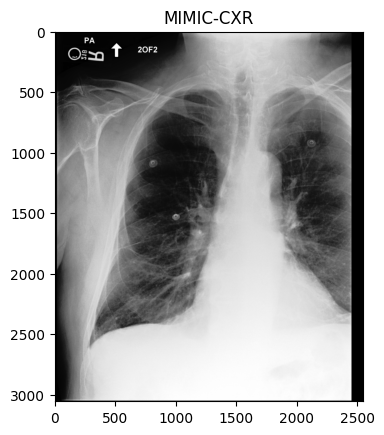

In [214]:
sample = d_mimic_test[11218]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("MIMIC-CXR")
#plt.savefig("mimic-cxr.png", dpi=300, bbox_inches="tight")
plt.show()

In [215]:
dict(zip(d_mimic_train.pathologies,sample["lab"]))

{np.str_('Atelectasis'): np.float32(0.0),
 np.str_('Cardiomegaly'): np.float32(0.0),
 np.str_('Consolidation'): np.float32(0.0),
 np.str_('Edema'): np.float32(0.0),
 np.str_('Enlarged Cardiomediastinum'): np.float32(0.0),
 np.str_('Fracture'): np.float32(0.0),
 np.str_('Lung Lesion'): np.float32(0.0),
 np.str_('Lung Opacity'): np.float32(0.0),
 np.str_('Effusion'): np.float32(0.0),
 np.str_('Pleural Other'): np.float32(0.0),
 np.str_('Pneumonia'): np.float32(0.0),
 np.str_('Pneumothorax'): np.float32(0.0),
 np.str_('Support Devices'): np.float32(0.0)}

## ✅ CheXpert Dataset

In [190]:
d_chex_train = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/data/chex_train_split.csv",
                                         views=["PA","AP","L"], unique_patients=False)
d_chex_selection = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/data/train_chex_selection_split.csv",
                                         views=["PA","AP","L"], unique_patients=False)
d_chex_test = xrv.datasets.CheX_Dataset(imgpath="/home/varrel/imaging/all_images/CheX_dataset/images_all/CheXpert-v1.0",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/data/train_chex_test_split.csv",
                                         views=["PA","AP","L"], unique_patients=False)

In [191]:
d_chex_train

{np.str_('Atelectasis'): {np.float32(0.0): 79600, np.float32(1.0): 98833},
 np.str_('Cardiomegaly'): {np.float32(0.0): 81563, np.float32(1.0): 96870},
 np.str_('Consolidation'): {np.float32(0.0): 93112, np.float32(1.0): 85321},
 np.str_('Edema'): {np.float32(0.0): 103220, np.float32(1.0): 75213},
 np.str_('Effusion'): {np.float32(0.0): 95938, np.float32(1.0): 82495},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 63985,
                                         np.float32(1.0): 114448},
 np.str_('Fracture'): {np.float32(0.0): 134143, np.float32(1.0): 44290},
 np.str_('Lung Lesion'): {np.float32(0.0): 154721, np.float32(1.0): 23712},
 np.str_('Lung Opacity'): {np.float32(0.0): 57590, np.float32(1.0): 120843},
 np.str_('Pleural Other'): {np.float32(0.0): 160945, np.float32(1.0): 17488},
 np.str_('Pneumonia'): {np.float32(0.0): 138141, np.float32(1.0): 40292},
 np.str_('Pneumothorax'): {np.float32(0.0): 158943, np.float32(1.0): 19490},
 np.str_('Support Devices'): {np.float32(0.

CheX_Dataset num_samples=178433 views=['PA', 'AP', 'L'] data_aug=None

In [192]:
d_chex_selection

{np.str_('Atelectasis'): {np.float32(0.0): 9851, np.float32(1.0): 12458},
 np.str_('Cardiomegaly'): {np.float32(0.0): 10047, np.float32(1.0): 12262},
 np.str_('Consolidation'): {np.float32(0.0): 11562, np.float32(1.0): 10747},
 np.str_('Edema'): {np.float32(0.0): 12877, np.float32(1.0): 9432},
 np.str_('Effusion'): {np.float32(0.0): 11866, np.float32(1.0): 10443},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 7929,
                                         np.float32(1.0): 14380},
 np.str_('Fracture'): {np.float32(0.0): 16864, np.float32(1.0): 5445},
 np.str_('Lung Lesion'): {np.float32(0.0): 19355, np.float32(1.0): 2954},
 np.str_('Lung Opacity'): {np.float32(0.0): 7184, np.float32(1.0): 15125},
 np.str_('Pleural Other'): {np.float32(0.0): 20194, np.float32(1.0): 2115},
 np.str_('Pneumonia'): {np.float32(0.0): 17210, np.float32(1.0): 5099},
 np.str_('Pneumothorax'): {np.float32(0.0): 19889, np.float32(1.0): 2420},
 np.str_('Support Devices'): {np.float32(0.0): 8645, np.floa

CheX_Dataset num_samples=22309 views=['PA', 'AP', 'L'] data_aug=None

In [193]:
d_chex_test

{np.str_('Atelectasis'): {np.float32(0.0): 10107, np.float32(1.0): 12548},
 np.str_('Cardiomegaly'): {np.float32(0.0): 10314, np.float32(1.0): 12341},
 np.str_('Consolidation'): {np.float32(0.0): 11764, np.float32(1.0): 10891},
 np.str_('Edema'): {np.float32(0.0): 12945, np.float32(1.0): 9710},
 np.str_('Effusion'): {np.float32(0.0): 12127, np.float32(1.0): 10528},
 np.str_('Enlarged Cardiomediastinum'): {np.float32(0.0): 8001,
                                         np.float32(1.0): 14654},
 np.str_('Fracture'): {np.float32(0.0): 16943, np.float32(1.0): 5712},
 np.str_('Lung Lesion'): {np.float32(0.0): 19552, np.float32(1.0): 3103},
 np.str_('Lung Opacity'): {np.float32(0.0): 7201, np.float32(1.0): 15454},
 np.str_('Pleural Other'): {np.float32(0.0): 20363, np.float32(1.0): 2292},
 np.str_('Pneumonia'): {np.float32(0.0): 17474, np.float32(1.0): 5181},
 np.str_('Pneumothorax'): {np.float32(0.0): 20204, np.float32(1.0): 2451},
 np.str_('Support Devices'): {np.float32(0.0): 8967, np.flo

CheX_Dataset num_samples=22655 views=['PA', 'AP', 'L'] data_aug=None

In [57]:
d_chex.pathologies

[np.str_('Atelectasis'),
 np.str_('Cardiomegaly'),
 np.str_('Consolidation'),
 np.str_('Edema'),
 np.str_('Enlarged Cardiomediastinum'),
 np.str_('Fracture'),
 np.str_('Lung Lesion'),
 np.str_('Lung Opacity'),
 np.str_('Effusion'),
 np.str_('Pleural Other'),
 np.str_('Pneumonia'),
 np.str_('Pneumothorax'),
 np.str_('Support Devices')]

In [58]:
d_chex.csv.iloc[444]

Path                          CheXpert-v1.0/train/patient00122/study6/view1_...
Sex                                                                      Female
Age                                                                        72.0
Frontal/Lateral                                                         Frontal
AP/PA                                                                        AP
Enlarged Cardiomediastinum                                                  1.0
Cardiomegaly                                                                1.0
Lung Opacity                                                                1.0
Lung Lesion                                                                 0.0
Edema                                                                       0.0
Consolidation                                                               1.0
Pneumonia                                                                   0.0
Atelectasis                             

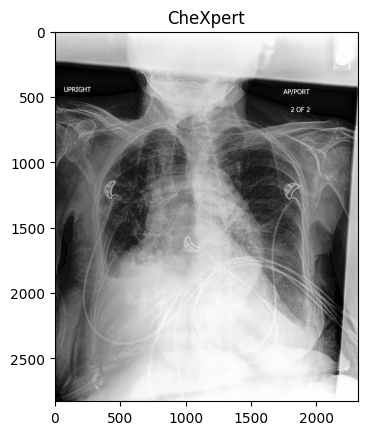

In [196]:
sample = d_chex_train[12237]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("CheXpert")
#plt.savefig("chexpert.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
dict(zip(d_chex.pathologies,sample["lab"]))

{np.str_('Atelectasis'): np.float32(0.0),
 np.str_('Cardiomegaly'): np.float32(0.0),
 np.str_('Consolidation'): np.float32(0.0),
 np.str_('Edema'): np.float32(0.0),
 np.str_('Enlarged Cardiomediastinum'): np.float32(0.0),
 np.str_('Fracture'): np.float32(0.0),
 np.str_('Lung Lesion'): np.float32(0.0),
 np.str_('Lung Opacity'): np.float32(0.0),
 np.str_('Effusion'): np.float32(0.0),
 np.str_('Pleural Other'): np.float32(0.0),
 np.str_('Pneumonia'): np.float32(0.0),
 np.str_('Pneumothorax'): np.float32(0.0),
 np.str_('Support Devices'): np.float32(0.0)}

## Shenzhen Dataset

In [34]:
d_shz = xrv.datasets.NLMTB_Dataset(imgpath="/home/varrel/imaging/all_images/SHZ_dataset/")

In [35]:
d_shz

{'Tuberculosis': {np.int64(0): 326, np.int64(1): 336}}


NLMTB_Dataset num_samples=662 views=['PA'] data_aug=None

In [36]:
d_shz.csv.iloc[21]

fname    CHNCXR_0022_0.png
label                    0
view                    PA
Name: 21, dtype: object

{'Tuberculosis': np.int64(0)}

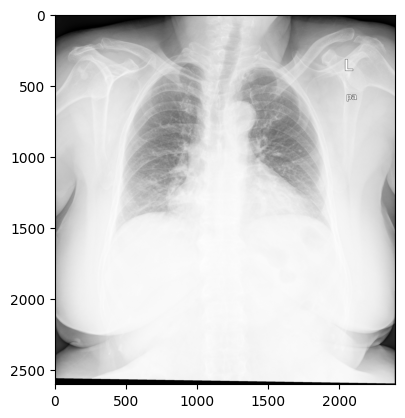

In [37]:
sample = d_shz[33]
plt.imshow(sample["img"][0], cmap="Greys_r");
dict(zip(d_shz.pathologies,sample["lab"]))

## Montgomery Dataset

In [38]:
d_mgm = xrv.datasets.NLMTB_Dataset(imgpath="/home/varrel/imaging/all_images/MGM_dataset/")

In [39]:
d_mgm

{'Tuberculosis': {np.int64(0): 80, np.int64(1): 58}}


NLMTB_Dataset num_samples=138 views=['PA'] data_aug=None

In [40]:
d_mgm.csv.iloc[17]

fname    MCUCXR_0024_0.png
label                    0
view                    PA
Name: 17, dtype: object

{'Tuberculosis': np.int64(0)}

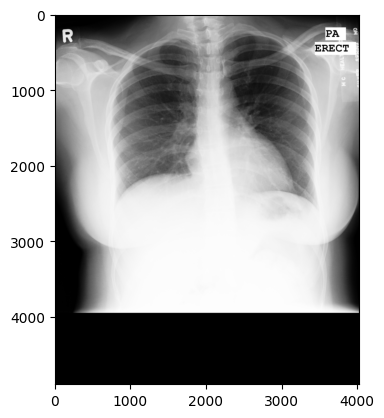

In [41]:
sample = d_mgm[17]
plt.imshow(sample["img"][0], cmap="Greys_r");
dict(zip(d_mgm.pathologies,sample["lab"]))

## Stony-Brook Dataset

In [8]:
d_sb = xrv.datasets.StonyBrookCOVID_Dataset(imgpath="/home/varrel/imaging/all_images/SB_dataset/images_all",
                                             csvpath="/home/varrel/imaging/all_images/SB_dataset/ralo-dataset-metadata.csv")

In [11]:
d_sb.__repr__

{'Geographic Extent': {np.float32(0.0): 69,
                       np.float32(0.5): 32,
                       np.float32(1.0): 75,
                       np.float32(1.5): 54,
                       np.float32(2.0): 122,
                       np.float32(2.5): 76,
                       np.float32(3.0): 108,
                       np.float32(3.5): 90,
                       np.float32(4.0): 161,
                       np.float32(4.5): 134,
                       np.float32(5.0): 193,
                       np.float32(5.5): 162,
                       np.float32(6.0): 228,
                       np.float32(6.5): 146,
                       np.float32(7.0): 266,
                       np.float32(7.5): 126,
                       np.float32(8.0): 331},
 'Lung Opacity': {np.float32(0.0): 70,
                  np.float32(0.5): 27,
                  np.float32(1.0): 64,
                  np.float32(1.5): 51,
                  np.float32(2.0): 262,
                  np.float32(2.5): 153,
    

<bound method Dataset.__repr__ of StonyBrookCOVID_Dataset num_samples=2373>

In [12]:
d_sb.csv.iloc[107]

Subject_ID                         S11159
Exam_DateTime         20200402_002723.787
Right GEOGRAPHIC                      4.0
Right OPACITY                         2.0
Left GEOGRAPHIC                       4.0
Left OPACITY                          2.0
Total GEOGRAPHIC                        8
Total OPACITY                           4
Notes                                 NaN
Right GEOGRAPHIC.1                    4.0
Right OPACITY.1                       2.0
Left GEOGRAPHIC.1                     4.0
Left OPACITY.1                        2.0
Total GEOGRAPHIC.1                      8
Total OPACITY.1                         4
Notes.1                               NaN
Delta Geo-total                         0
Delta Opa total                         0
Geographic Extent                     8.0
Lung Opacity                          4.0
offset_day_int                      18354
patientid                          S11159
view                                   AP
Name: 107, dtype: object

{'Geographic Extent': np.float32(0.0), 'Lung Opacity': np.float32(0.0)}

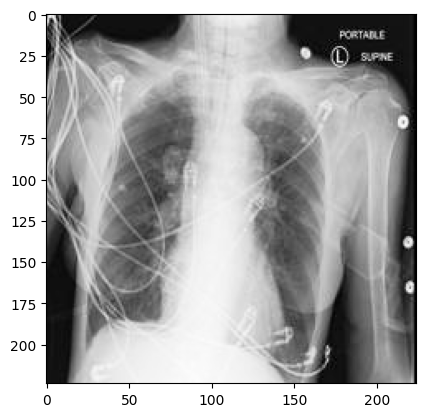

In [13]:
sample = d_sb[1000]
plt.imshow(sample["img"][0], cmap="Greys_r");
dict(zip(d_sb.pathologies,sample["lab"]))

## ✅ SIIM-ACR Dataset

In [4]:
d_siim_train = xrv.datasets.SIIM_Pneumothorax_Dataset(imgpath="/home/varrel/imaging/all_images/SIIM_dataset/dicom-images-train/",
                                                      csvpath="/home/varrel/GitHub/CXR-Analysis/data/siim_train_split.csv")
d_siim_selection = xrv.datasets.SIIM_Pneumothorax_Dataset(imgpath="/home/varrel/imaging/all_images/SIIM_dataset/dicom-images-train/",
                                                      csvpath="/home/varrel/GitHub/CXR-Analysis/data/siim_selection_split.csv")
d_siim_test = xrv.datasets.SIIM_Pneumothorax_Dataset(imgpath="/home/varrel/imaging/all_images/SIIM_dataset/dicom-images-train/",
                                                      csvpath="/home/varrel/GitHub/CXR-Analysis/data/siim_test_split.csv")

In [12]:
valid_paths = np.load("/home/varrel/GitHub/CXR-Analysis/model/clean_image_index_npy/mimic_scan_valid.npy", allow_pickle=True)
print(valid_paths[:5])

['/home/varrel/imaging/all_images/MIMIC_dataset/images_all/p18/p18579410/s55486691/bf902ac6-dd69c454-d890087d-c2a62dfc-e2730eb3.jpg'
 '/home/varrel/imaging/all_images/MIMIC_dataset/images_all/p18/p18579410/s55486691/705ed6c0-8bf85eb3-76e9abd2-d3fb82be-56560548.jpg'
 '/home/varrel/imaging/all_images/MIMIC_dataset/images_all/p18/p18579410/s55486691/adb58d21-f0c0b49e-62007f1c-81bac94d-b237a351.jpg'
 '/home/varrel/imaging/all_images/MIMIC_dataset/images_all/p18/p18579410/s55486691/816463d8-7da3c6a2-e5cd644c-f9d425de-544cb38d.jpg'
 '/home/varrel/imaging/all_images/MIMIC_dataset/images_all/p18/p18579410/s58111249/3ba80d6e-3aa530bd-38ab09f2-8feed963-71b471d4.jpg']


In [ ]:
# Load your split CSV
df = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/mimic_train_split.csv")

# Load valid paths
valid_paths = np.load("/home/varrel/GitHub/CXR-Analysis/model/clean_image_index_npy/mimic_scan_valid.npy", allow_pickle=True)

# Convert to DataFrame
valid_df = pd.DataFrame({"path": valid_paths})

# Extract subject_id and study_id from the path
valid_df["subject_id"] = valid_df["path"].apply(lambda x: int(x.split("/p")[-1].split("/")[0]))
valid_df["study_id"]   = valid_df["path"].apply(lambda x: int(x.split("/s")[-1].split("/")[0]))

# Merge with your CSV on subject_id + study_id
df_clean = pd.merge(valid_df, df, on=["subject_id","study_id"], how="inner")
df_clean = df_clean.drop_duplicates(subset=["subject_id","study_id"])

print(f"Original rows: {len(df)}, Cleaned rows: {len(df_clean)}")

# Save cleaned CSV
df_clean.to_csv("mimic_train_split_clean.csv", index=False)

Original rows: 178413, Cleaned rows: 295361


In [11]:
df = pd.read_csv("/home/varrel/GitHub/CXR-Analysis/data/siim_train_split.csv")
valid_indices = np.load("/home/varrel/GitHub/CXR-Analysis/model/clean_image_index_npy/siim_scan_valid.npy", allow_pickle=True)
df_clean = df.iloc[valid_indices]
print(f"Original rows: {len(df)}, Cleaned rows: {len(df_clean)}")
df_clean.to_csv("siim_train_split_clean.csv", index=False)

Original rows: 10363, Cleaned rows: 10363


In [9]:
valid_set

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

In [31]:
d_siim_train

{'Pneumothorax': {np.float32(0.0): 7502, np.float32(1.0): 2861}}


SIIM_Pneumothorax_Dataset num_samples=10363 data_aug=None

In [33]:
d_siim_selection

{'Pneumothorax': {np.float32(0.0): 938, np.float32(1.0): 357}}


SIIM_Pneumothorax_Dataset num_samples=1295 data_aug=None

In [34]:
d_siim_test

{'Pneumothorax': {np.float32(0.0): 938, np.float32(1.0): 358}}


SIIM_Pneumothorax_Dataset num_samples=1296 data_aug=None

In [38]:
d_siim_selection.csv.iloc[1237]

index                                                          1237
ImageId           1.2.276.0.7230010.3.1.4.8323329.10519.15178752...
 EncodedPixels                                                   -1
EncodedPixels                                                    -1
has_masks                                                     False
Name: 1237, dtype: object

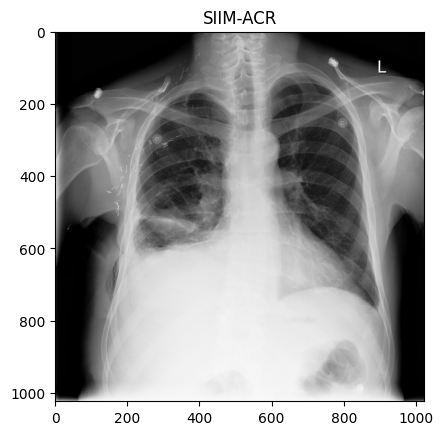

In [40]:
sample = d_siim_selection[1200]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("SIIM-ACR")
#plt.savefig("siim_acr.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
dict(zip(d_siim_selection.pathologies,sample["lab"]))

{'Pneumothorax': np.float32(1.0)}

## ✅ Object CXR

In [54]:
d_ox_train = xrv.datasets.ObjectCXR_Dataset(imgzippath="/home/varrel/imaging/all_images/OX_dataset/train.zip",
                                            csvpath="/home/varrel/GitHub/CXR-Analysis/data/ox_train_split.csv")
d_ox_selection = xrv.datasets.ObjectCXR_Dataset(imgzippath="/home/varrel/imaging/all_images/OX_dataset/train.zip",
                                                csvpath="/home/varrel/GitHub/CXR-Analysis/data/ox_selection_split.csv")
d_ox_test = xrv.datasets.ObjectCXR_Dataset(imgzippath="/home/varrel/test_images/OX_dataset/images_all/dev.zip",
                                           csvpath="/home/varrel/test_images/OX_dataset/images_all/dev.csv")

In [48]:
d_ox_train

{'Foreign Object': {np.float32(0.0): 3600, np.float32(1.0): 3600}}


ObjectCXR_Dataset num_samples=7200 views=[] data_aug=None

In [49]:
d_ox_selection

{'Foreign Object': {np.float32(0.0): 400, np.float32(1.0): 400}}


ObjectCXR_Dataset num_samples=800 views=[] data_aug=None

In [50]:
d_ox_test

{'Foreign Object': {np.float32(0.0): 500, np.float32(1.0): 500}}


ObjectCXR_Dataset num_samples=1000 views=[] data_aug=None

In [51]:
d_ox_selection.csv.iloc[331]

index               331
image_name    04963.jpg
annotation          NaN
label                 0
has_masks         False
Name: 331, dtype: object

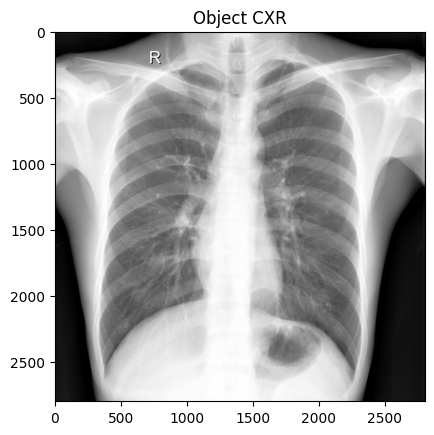

In [55]:
sample = d_ox_selection[799]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("Object CXR")
#plt.savefig("object_cxr.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
# Optional: show the labels dictionary
print(dict(zip(d_ox_selection.pathologies, sample["lab"])))

{'Foreign Object': np.float32(1.0)}


## ✅ RSNA Pneumonia

In [102]:
d_rsna_train = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/imaging/all_images/RSNA_dataset/stage_2_train_images_jpg",
                                                   csvpath="/home/varrel/GitHub/CXR-Analysis/data/rsna_train_split.csv",
                                                   views=["PA","AP"])
d_rsna_selection = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/imaging/all_images/RSNA_dataset/stage_2_train_images_jpg",
                                                       csvpath="/home/varrel/GitHub/CXR-Analysis/data/rsna_selection_split.csv",
                                                       views=["PA","AP"])
d_rsna_test = xrv.datasets.RSNA_Pneumonia_Dataset(imgpath="/home/varrel/test_images/RSNA_dataset/images_all",
                                                  csvpath="/home/varrel/GitHub/CXR-Analysis/data/rsna_test_split.csv",
                                                  views=["PA","AP"])

In [97]:
d_rsna_train

{'Lung Opacity': {np.float32(0.0): 16537, np.float32(1.0): 4810},
 'Pneumonia': {np.float32(0.0): 16537, np.float32(1.0): 4810}}


RSNA_Pneumonia_Dataset num_samples=21347 views=['PA', 'AP'] data_aug=None

In [98]:
d_rsna_selection

{'Lung Opacity': {np.float32(0.0): 2067, np.float32(1.0): 601},
 'Pneumonia': {np.float32(0.0): 2067, np.float32(1.0): 601}}


RSNA_Pneumonia_Dataset num_samples=2668 views=['PA', 'AP'] data_aug=None

In [99]:
d_rsna_test

{'Lung Opacity': {np.float32(0.0): 2068, np.float32(1.0): 601},
 'Pneumonia': {np.float32(0.0): 2068, np.float32(1.0): 601}}


RSNA_Pneumonia_Dataset num_samples=2669 views=['PA', 'AP'] data_aug=None

In [94]:
d_rsna_train.csv.iloc[9331]

patientId                 7ccacf95-ccc2-446b-8f5c-08b32411bed6
x                                                          NaN
y                                                          NaN
width                                                      NaN
height                                                     NaN
Target                                                       0
Unnamed: 0                                               24758
BodyPartExamined                                         CHEST
ConversionType                                             WSD
Filename              7ccacf95-ccc2-446b-8f5c-08b32411bed6.dcm
InstanceNumber                                             1.0
Modality                                                    CR
PatientAge                                                  52
PatientOrientation                                         NaN
PatientSex                                                   F
PixelSpacing                                           

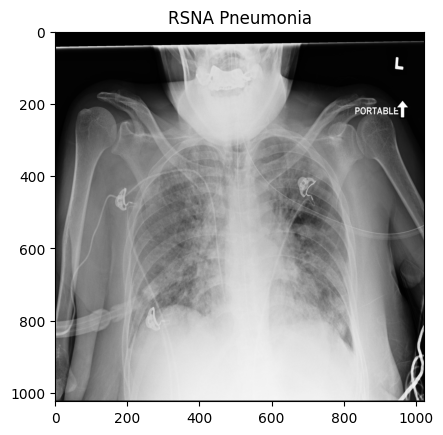

In [105]:
sample = d_rsna_test[350]
plt.imshow(sample["img"][0], cmap="Greys_r");
plt.title("RSNA Pneumonia")
#plt.savefig("rsna.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:
dict(zip(d_rsna.pathologies,sample["lab"]))

{'Lung Opacity': np.float32(0.0), 'Pneumonia': np.float32(0.0)}

## Kermany Dataset

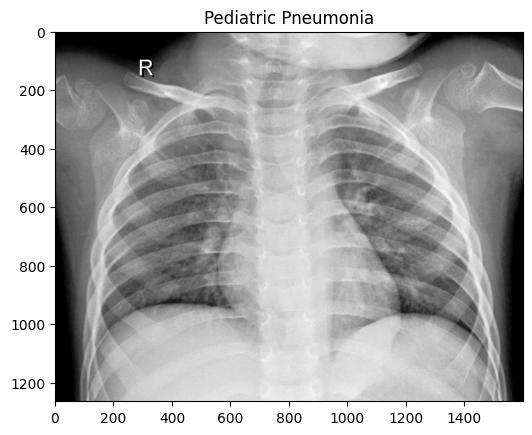

In [95]:
import skimage.io as io

image_dir = r"/home/varrel/imaging/all_images/PP_dataset/images_all/Pediatric Chest X-ray Pneumonia/train/NORMAL/IM-0466-0001.jpeg"

img = io.imread(image_dir)
plt.imshow(img, cmap="Greys_r")
plt.title("Pediatric Pneumonia")
plt.savefig("kermany.png", dpi=300, bbox_inches="tight")
plt.show()

## BRAX

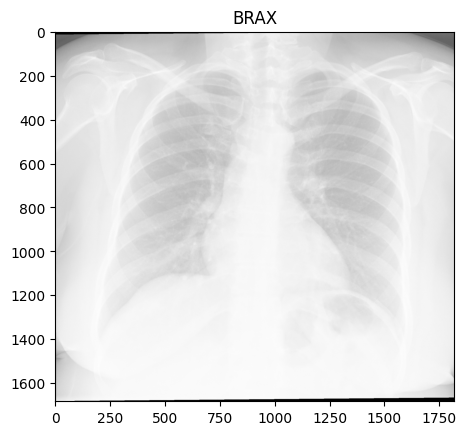

In [96]:
import pydicom
import skimage.io as io

image_dir = r"/home/varrel/imaging/physionet.org/files/brax/1.1.0/Anonymized_DICOMs/id_1e69e0dc-a428bd01-f304db65-bf90b88e-1abeb3b3/Study_60402953.23494316.33077573.87237968.96236698/Series_98990435.75216994.58165844.00534996.99415918/image-73764457-46268182-82089881-53270550-10694314.dcm"

ds = pydicom.dcmread(image_dir)
img = ds.pixel_array

plt.imshow(img, cmap="Greys_r")
plt.title("BRAX")
plt.savefig("brax.png", dpi=300, bbox_inches="tight")
plt.show()